In [2]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# ================= CONFIG =================
FILE_NAME = "telecom_customer_churn (1).csv"   # 👈 change only file name
# ==========================================

# ---------- Load Dataset ----------
df = pd.read_csv(FILE_NAME)

print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())

# ---------- Remove Duplicates ----------
df.drop_duplicates(inplace=True)

# ---------- Auto-detect Target ----------
TARGET_COL = df.columns[-1]
print("✅ Detected target column:", TARGET_COL)

# ---------- Separate Features & Target ----------
y = df[TARGET_COL]
X = df.drop(TARGET_COL, axis=1)

# ---------- Missing Value Handling ----------
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X[num_cols] = num_imputer.fit_transform(X[num_cols])
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

# ---------- Outlier Treatment (IQR Method) ----------
for col in num_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    X[col] = np.clip(X[col], lower, upper)

# ---------- Encoding Categorical ----------
for col in cat_cols:
    X[col] = pd.factorize(X[col])[0]

print("✅ Advanced Cleaning Completed")
print("Final Feature Shape:", X.shape)

Dataset Shape: (1500, 11)
Columns: ['customer_id', 'gender', 'age', 'tenure_months', 'monthly_charges', 'total_charges', 'contract_type', 'internet_service', 'support_calls', 'payment_method', 'churn']
✅ Detected target column: churn
✅ Advanced Cleaning Completed
Final Feature Shape: (1500, 10)


In [3]:
#task detection and train test split

In [5]:
from sklearn.model_selection import train_test_split

# ---------- Auto-detect ML task ----------
if y.dtype == "object" or y.nunique() <= 10:
    TASK_TYPE = "classification"
else:
    TASK_TYPE = "regression"

print("✅ Detected task type:", TASK_TYPE)

# ---------- Safe train-test split ----------
if TASK_TYPE == "classification":
    if y.value_counts().min() < 2:
        print("⚠️ Stratify disabled (rare class detected)")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

print("Train Shape:", X_train.shape)

✅ Detected task type: classification
Train Shape: (1200, 10)


In [6]:
#decidion tree baseline 

In [7]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    mean_squared_error,
    r2_score
)

# ---------- Train Decision Tree ----------
if TASK_TYPE == "classification":
    dt = DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )
else:
    dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print("\n🌳 Decision Tree Results")

if TASK_TYPE == "classification":
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))
else:
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))


🌳 Decision Tree Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       244
           1       1.00      1.00      1.00        56

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

ROC-AUC: 1.0


In [8]:
#overfitting experiment 

In [9]:
print("\n🔍 Overfitting Experiment (varying max_depth)\n")

depths = [None, 3, 5, 10]

for depth in depths:
    
    if TASK_TYPE == "classification":
        model = DecisionTreeClassifier(
            max_depth=depth,
            random_state=42,
            class_weight="balanced"
        )
    else:
        model = DecisionTreeRegressor(
            max_depth=depth,
            random_state=42
        )

    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(f"Depth: {depth}")
    print("Train Score:", train_score)
    print("Test Score:", test_score)
    print("-"*40)


🔍 Overfitting Experiment (varying max_depth)

Depth: None
Train Score: 1.0
Test Score: 1.0
----------------------------------------
Depth: 3
Train Score: 1.0
Test Score: 1.0
----------------------------------------
Depth: 5
Train Score: 1.0
Test Score: 1.0
----------------------------------------
Depth: 10
Train Score: 1.0
Test Score: 1.0
----------------------------------------


In [ ]:
#grid search DT Tuning

In [11]:
from sklearn.model_selection import GridSearchCV

if TASK_TYPE == "classification":
    param_grid = {
        "max_depth": [None, 3, 5, 10],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "criterion": ["gini", "entropy"]
    }
    
    grid = GridSearchCV(
        DecisionTreeClassifier(random_state=42, class_weight="balanced"),
        param_grid,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )
else:
    param_grid = {
        "max_depth": [None, 3, 5, 10],
        "min_samples_split": [2, 5, 10]
    }
    
    grid = GridSearchCV(
        DecisionTreeRegressor(random_state=42),
        param_grid,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

grid.fit(X_train, y_train)

print("✅ Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

✅ Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.9978021978021978


In [12]:
#ANN Scaling + Architecture

In [13]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def build_ann(neurons=64, dropout=0.3, lr=0.001):
    
    model = keras.Sequential([
        layers.Dense(neurons,
                     activation="relu",
                     kernel_regularizer=regularizers.l2(0.001),
                     input_shape=(X_train.shape[1],)),
        layers.Dropout(dropout),
        layers.Dense(neurons//2, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid")
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [14]:
#TRAIN ANN(EarlyStopping + LR Scheduling)

In [15]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
]

ann = build_ann()

history = ann.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

loss, acc = ann.evaluate(X_test_scaled, y_test)
print("✅ ANN Test Accuracy:", acc)

c:\Users\User\Downloads\007\.conda\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7958 - loss: 0.5329 - val_accuracy: 0.8167 - val_loss: 0.4347 - learning_rate: 0.0010
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8115 - loss: 0.4582 - val_accuracy: 0.8167 - val_loss: 0.3792 - learning_rate: 0.0010
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8260 - loss: 0.4012 - val_accuracy: 0.8458 - val_loss: 0.3389 - learning_rate: 0.0010
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8365 - loss: 0.3646 - val_accuracy: 0.8708 - val_loss: 0.3063 - learning_rate: 0.0010
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8458 - loss: 0.3364 - val_accuracy: 0.8958 - val_loss: 0.2835 - learning_rate: 0.0010
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8667 - loss: 0.3160 - val_accuracy: 0.9042 - val_loss: 0.2683 - learning_rate: 0.0010
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8583 - loss: 0.3152 - val_ac

In [16]:
#OPTUNA HYPERPARAMETER OPTIMIZATION

In [17]:
import optuna

def objective(trial):
    
    neurons = trial.suggest_int("neurons", 32, 128)
    dropout = trial.suggest_float("dropout", 0.2, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    
    model = build_ann(neurons, dropout, lr)
    
    model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=batch_size,
        verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(patience=5)]
    )
    
    _, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
    return accuracy

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("🏆 Best Params:", study.best_params)
print("Best Accuracy:", study.best_value)

c:\Users\User\Downloads\007\.conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-02 10:03:50,478] A new study created in memory with name: no-name-204b4598-77fc-4aa3-8d19-b9fc99004117
c:\Users\User\Downloads\007\.conda\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-03-02 10:03:58,282] Trial 0 finished with value: 0.9666666388511658 and parameters: {'neurons': 62, 'dropout': 0.33918471888484736, 'lr': 0.0034374378041863315, 'batch_size': 32}. Best is trial 0 with value: 0.9666666388511658.
[I 2026-03-02 10:04:04,872] Trial 1 finished wit

🏆 Best Params: {'neurons': 39, 'dropout': 0.3854280556993112, 'lr': 0.0022870451812373417, 'batch_size': 16}
Best Accuracy: 0.9800000190734863


In [18]:
#Final Comparison

In [19]:
print("\n📊 FINAL MODEL COMPARISON\n")

dt_score = grid.best_estimator_.score(X_test, y_test)
print("Decision Tree Score:", dt_score)
print("ANN Score:", acc)


📊 FINAL MODEL COMPARISON

Decision Tree Score: 1.0
ANN Score: 0.9633333086967468


In [20]:
#boas variancre nalysis 

In [21]:
print("\n📊 Bias-Variance Analysis\n")

# Decision Tree
dt_train_acc = grid.best_estimator_.score(X_train, y_train)
dt_test_acc = grid.best_estimator_.score(X_test, y_test)

print("Decision Tree")
print("Train Score:", dt_train_acc)
print("Test Score:", dt_test_acc)

# ANN
ann_train_loss, ann_train_acc = ann.evaluate(X_train_scaled, y_train, verbose=0)
ann_test_loss, ann_test_acc = ann.evaluate(X_test_scaled, y_test, verbose=0)

print("\nANN")
print("Train Accuracy:", ann_train_acc)
print("Test Accuracy:", ann_test_acc)

print("\n🔎 Interpretation:")
if dt_train_acc - dt_test_acc > 0.1:
    print("DT shows High Variance (Overfitting)")
else:
    print("DT relatively stable")

if ann_train_acc - ann_test_acc > 0.1:
    print("ANN shows High Variance")
else:
    print("ANN generalizes better")


📊 Bias-Variance Analysis

Decision Tree
Train Score: 1.0
Test Score: 1.0

ANN
Train Accuracy: 0.9916666746139526
Test Accuracy: 0.9633333086967468

🔎 Interpretation:
DT relatively stable
ANN generalizes better


In [22]:
#ROBUSTNESS CHECK (Label Noise Experiment)

In [23]:
print("\n🛡 Robustness to Label Noise\n")

# Add artificial noise (10%)
noise_fraction = 0.1
y_noisy = y_train.copy()

noise_indices = np.random.choice(
    y_noisy.index,
    size=int(len(y_noisy)*noise_fraction),
    replace=False
)

y_noisy.loc[noise_indices] = 1 - y_noisy.loc[noise_indices]

# Retrain DT on noisy data
dt_noise = DecisionTreeClassifier(random_state=42)
dt_noise.fit(X_train, y_noisy)
dt_noise_score = dt_noise.score(X_test, y_test)

print("DT Score with Noise:", dt_noise_score)

# Retrain ANN on noisy data
ann_noise = build_ann()
ann_noise.fit(
    X_train_scaled, y_noisy,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

_, ann_noise_score = ann_noise.evaluate(X_test_scaled, y_test, verbose=0)

print("ANN Score with Noise:", ann_noise_score)


🛡 Robustness to Label Noise

DT Score with Noise: 0.8933333333333333


c:\Users\User\Downloads\007\.conda\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ANN Score with Noise: 0.9466666579246521


In [24]:
#MANUAL TUNING vs AUTOMATED TUNING

In [25]:
print("\n⚖ Manual vs Automated Tuning Comparison\n")

# -------- Manual Tuning Example --------
manual_dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    criterion="entropy",
    random_state=42
)

manual_dt.fit(X_train, y_train)
manual_score = manual_dt.score(X_test, y_test)

print("Manual DT Score:", manual_score)

# -------- Automated (GridSearch) --------
auto_score = grid.best_estimator_.score(X_test, y_test)

print("Automated GridSearch DT Score:", auto_score)

print("\nOptuna ANN Score:", study.best_value)
print("Manual ANN Score:", acc)


⚖ Manual vs Automated Tuning Comparison

Manual DT Score: 1.0
Automated GridSearch DT Score: 1.0

Optuna ANN Score: 0.9800000190734863
Manual ANN Score: 0.9633333086967468


In [26]:
#plot model

In [30]:
!pip install pydot 

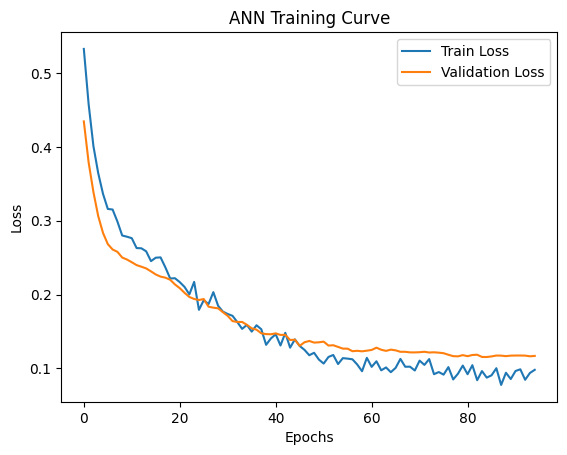

In [32]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Train Loss", "Validation Loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("ANN Training Curve")
plt.show()


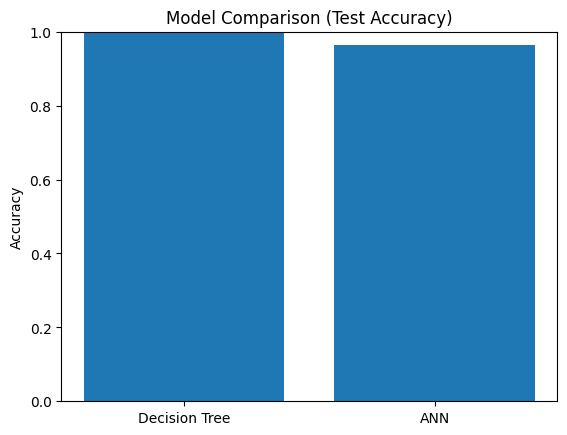

In [33]:
import matplotlib.pyplot as plt

# Scores
dt_score = grid.best_estimator_.score(X_test, y_test)
ann_score = acc   # ANN test accuracy

models = ["Decision Tree", "ANN"]
scores = [dt_score, ann_score]

plt.figure()
plt.bar(models, scores)
plt.title("Model Comparison (Test Accuracy)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()